In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import seaborn as sns

In [6]:
df = pd.read_csv('dissertation/full_image_data_feb_25.csv')


In [7]:
books = pd.read_csv('/Users/nogashlomi/projects/image_data/dissertation/full_book_data_feb_25.csv')

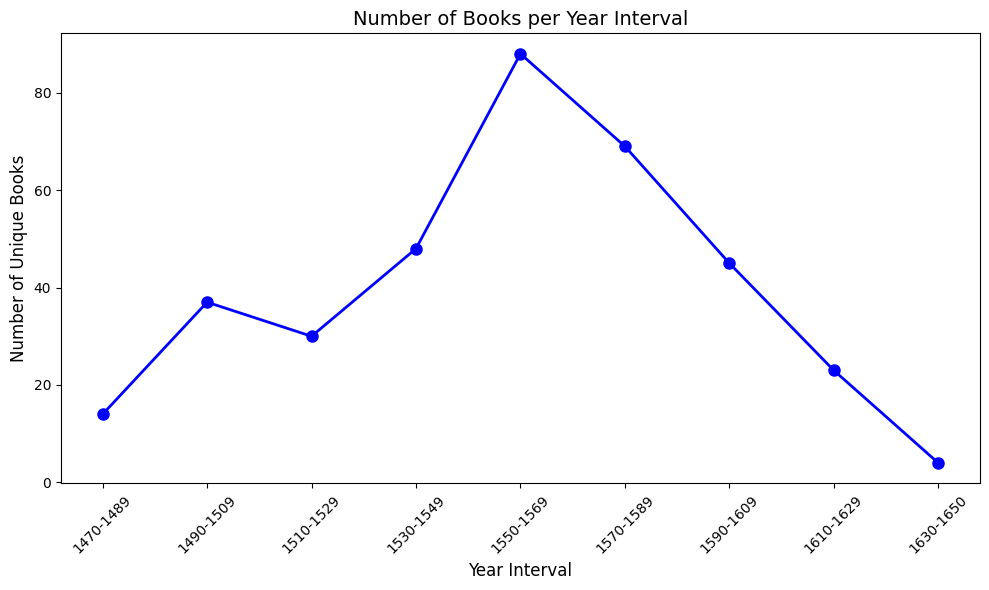

In [8]:

# Group by 'year_interval' and count the unique books
unique_books_per_interval = books.groupby('year_interval')['book'].nunique()

# Ensure the intervals are ordered correctly based on the 'year_interval' in your data
ordered_intervals = pd.Categorical(unique_books_per_interval.index, ordered=True)

# Reorder the Series by the correct order of 'year_interval'
unique_books_per_interval = unique_books_per_interval[ordered_intervals]

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(unique_books_per_interval.index, unique_books_per_interval, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)

# Improve the plot (labels, title, etc.)
plt.title('Number of Books per Year Interval', fontsize=14)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Number of Unique Books', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to avoid clipping of labels

# Show the plot
plt.show()


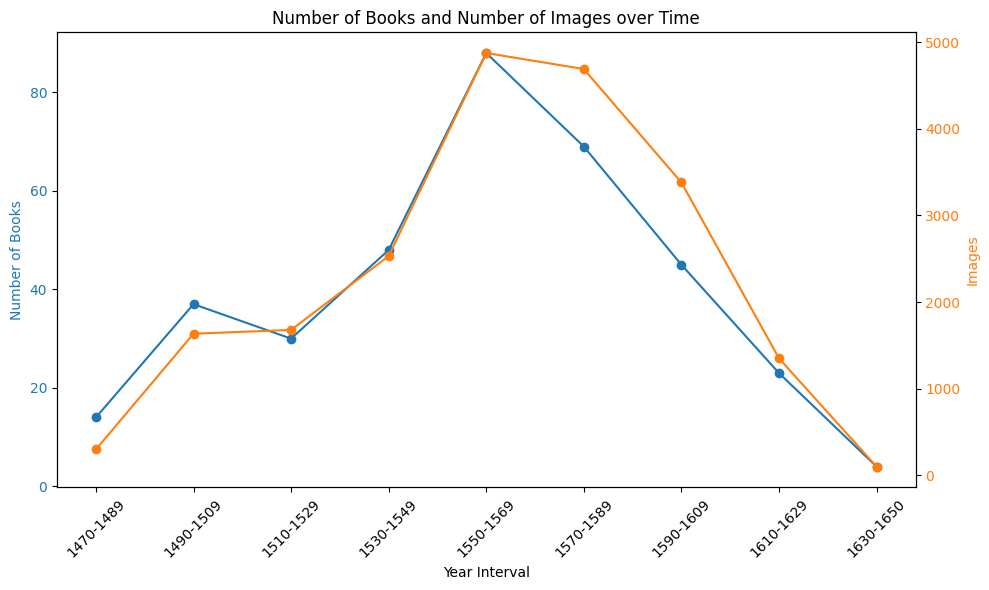

In [9]:

# Line 1: Number of unique book values per interval in books
book_counts = books.groupby('year_interval', observed=False)['book'].nunique()

# Line 2: Number of unique image values per interval in df
image_counts = df.groupby('year_interval', observed=False)['images'].nunique()

# Create the plot with two Y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first line (unique books) on the left Y-axis
ax1.plot(book_counts.index, book_counts.values, label='Unique Books', marker='o', color='tab:blue')
ax1.set_xlabel('Year Interval')
ax1.set_ylabel('Number of Books', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second Y-axis to plot unique images
ax2 = ax1.twinx()  
ax2.plot(image_counts.index, image_counts.values, label='Images', marker='o', color='tab:orange')
ax2.set_ylabel('Images', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Customize the plot
plt.title('Number of Books and Number of Images over Time')

# Adjust x-axis labels to show rotated years without the warning
ax1.set_xticks(range(len(book_counts.index)))  # Set the tick positions
ax1.set_xticklabels(book_counts.index, rotation=45)  # Set the labels

fig.tight_layout()

# Show the plot
plt.show()


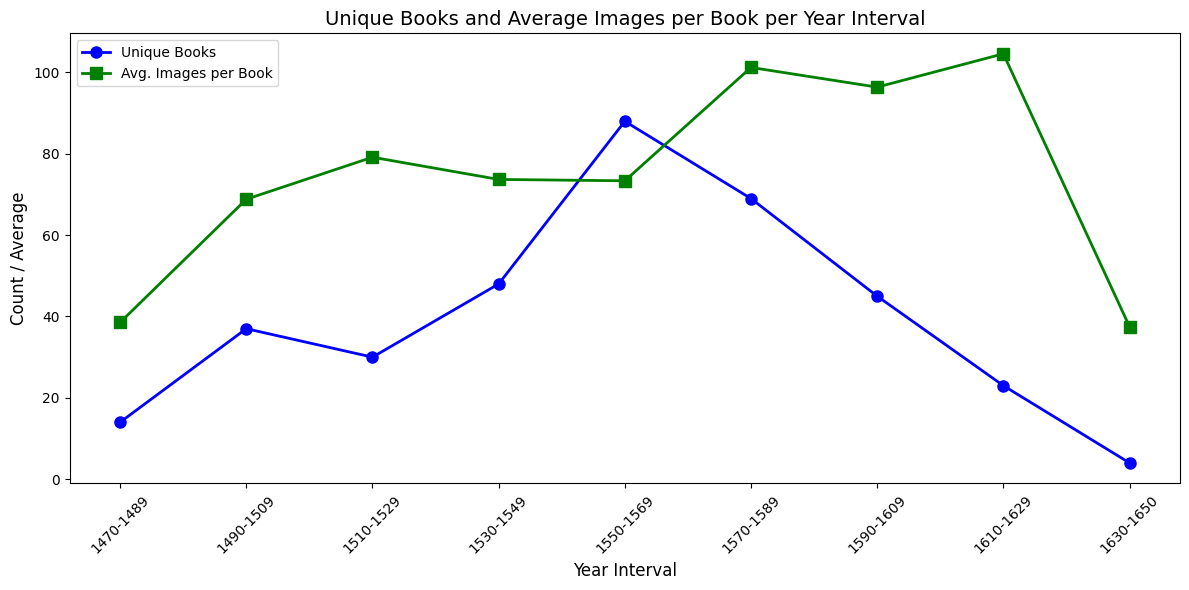

In [10]:
#average images per book

# 1. Group 'books' DataFrame by 'year_interval' and count unique books
unique_books_per_interval = books.groupby('year_interval')['book'].nunique()

# 2. Group 'df' DataFrame by 'year_interval' and calculate the total number of images per book
# Calculate the total number of images for each book
total_images_per_book = df.groupby(['year_interval', 'book'])['images'].count()

# Now calculate the average images per book per interval
avg_images_per_book_per_interval = total_images_per_book.groupby('year_interval').mean()

# Ensure intervals are ordered chronologically
ordered_intervals = pd.Categorical(unique_books_per_interval.index, ordered=True)

# Reorder the series to ensure correct order of 'year_interval'
unique_books_per_interval = unique_books_per_interval[ordered_intervals]
avg_images_per_book_per_interval = avg_images_per_book_per_interval[ordered_intervals]

# Create a plot
plt.figure(figsize=(12, 6))

# Plot the unique books line
plt.plot(unique_books_per_interval.index, unique_books_per_interval, marker='o', label='Unique Books', color='b', linestyle='-', linewidth=2, markersize=8)

# Plot the average images per book line
plt.plot(avg_images_per_book_per_interval.index, avg_images_per_book_per_interval, marker='s', label='Avg. Images per Book', color='g', linestyle='-', linewidth=2, markersize=8)

# Improve the plot (labels, title, etc.)
plt.title('Unique Books and Average Images per Book per Year Interval', fontsize=14)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Count / Average', fontsize=12)
plt.xticks(rotation=45)

# Add legend
plt.legend()

# Adjust layout to avoid clipping of labels
plt.tight_layout()

# Save the plot in the current working directory with the given filename
plt.savefig('ave_image_book.png', dpi=300)

# Show the plot
plt.show()


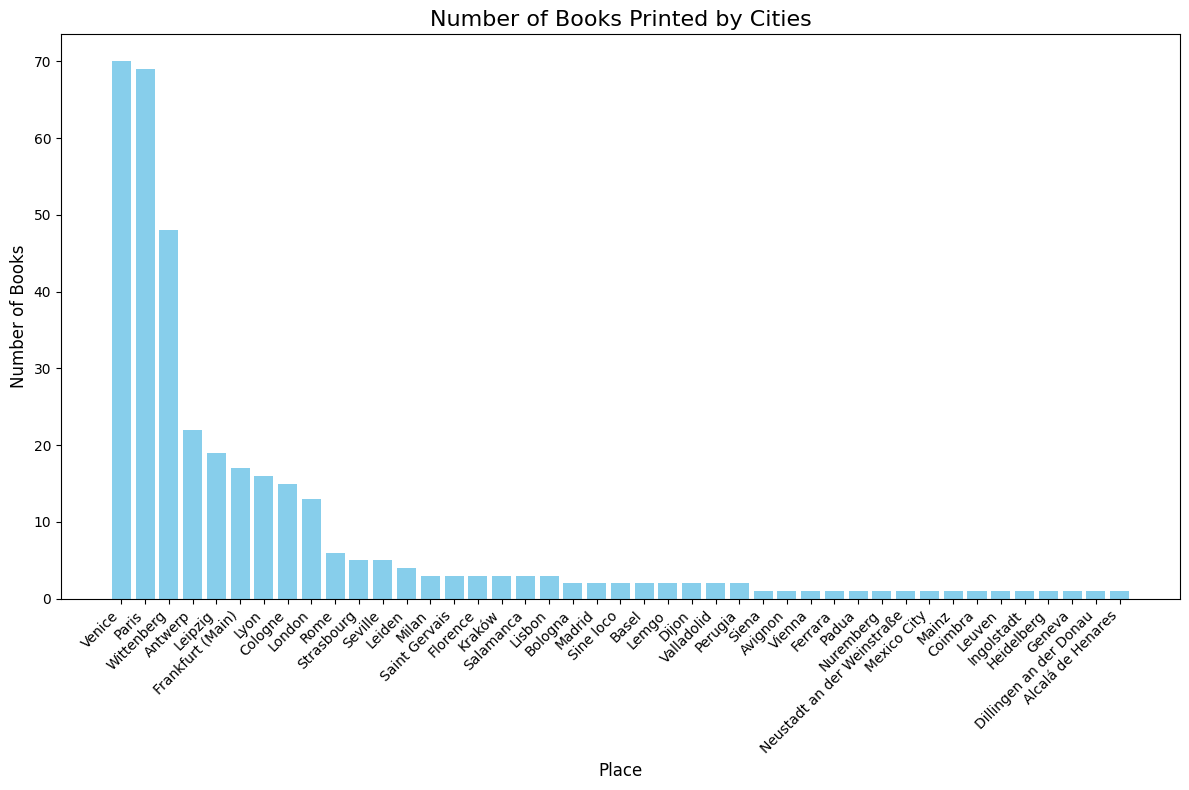

In [19]:
#number of books by place

# Group by 'place' and count the number of books in each category
books_per_place = books.groupby('place')['book'].nunique()

# Sort the categories by the number of books in descending order
books_per_place = books_per_place.sort_values(ascending=False)

# Plotting the results using a bar plot in Matplotlib
plt.figure(figsize=(12, 8))
plt.bar(books_per_place.index, books_per_place.values, color='skyblue')

# Add titles and labels
plt.title('Number of Books Printed by Cities', fontsize=16)
plt.xlabel('Place', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better visibility

# Improve layout to prevent label clipping
plt.tight_layout()

# Save the plot in the current working directory with the given filename
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/place_num_books.png', dpi=300)

# Show the plot
plt.show()


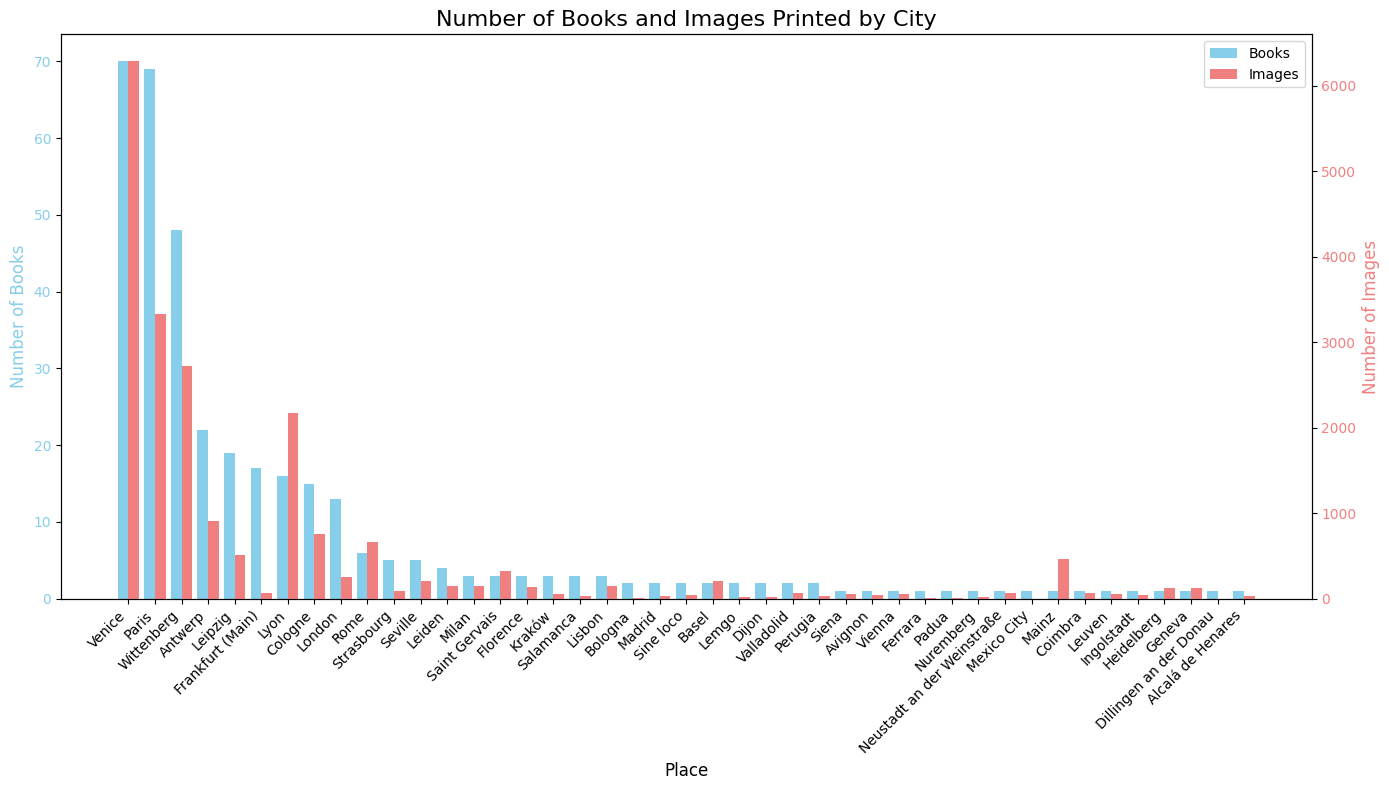

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Group and count books per place
books_per_place = books.groupby('place')['book'].nunique()

# Group and count unique images per place (correct column name: 'images')
images_per_place = df.groupby('place')['images'].nunique()

# Combine both into a single DataFrame
place_stats = pd.concat([books_per_place, images_per_place], axis=1)
place_stats.columns = ['Number of Books', 'Number of Images']
place_stats = place_stats.fillna(0)

# Sort by number of books
place_stats = place_stats.sort_values(by='Number of Books', ascending=False)

# Set up figure and axis
fig, ax1 = plt.subplots(figsize=(14, 8))

# X-axis locations and bar width
x = range(len(place_stats))
bar_width = 0.4

# Plot Number of Books
ax1.bar([p - bar_width/2 for p in x],
        place_stats['Number of Books'],
        width=bar_width,
        color='skyblue',
        label='Books')
ax1.set_ylabel('Number of Books', color='skyblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='skyblue')

# Plot Number of Images on secondary axis
ax2 = ax1.twinx()
ax2.bar([p + bar_width/2 for p in x],
        place_stats['Number of Images'],
        width=bar_width,
        color='lightcoral',
        label='Images')
ax2.set_ylabel('Number of Images', color='lightcoral', fontsize=12)
ax2.tick_params(axis='y', labelcolor='lightcoral')

# X-axis setup with rotated labels
ax1.set_xlabel('Place', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(place_stats.index, rotation=45, ha='right')  # <-- This now works correctly

# Title and legend
plt.title('Number of Books and Images Printed by City', fontsize=16)

# Combine legends from both axes
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc='upper right')

# Final layout and save
plt.tight_layout()
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/place_books_images_dual_axis.png', dpi=300)
plt.show()


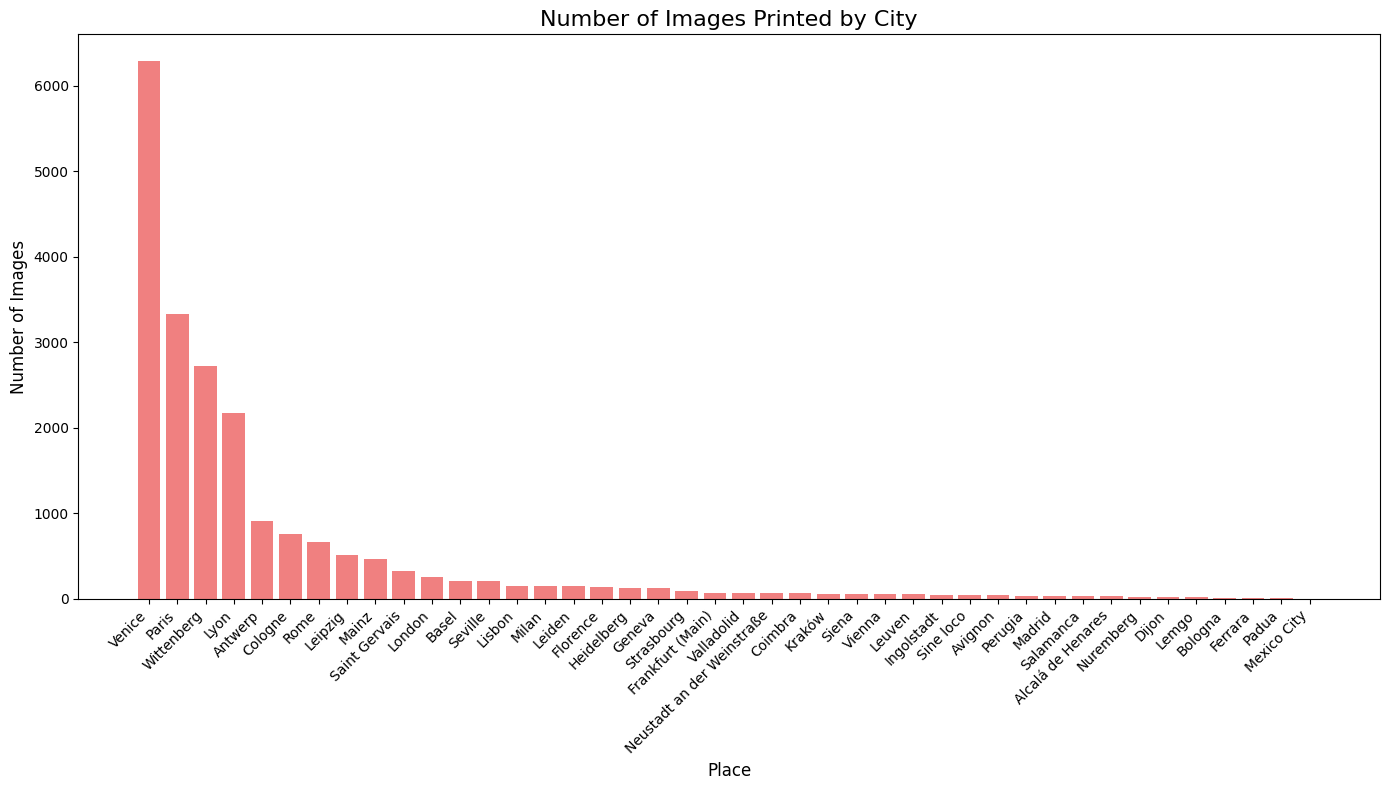

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Group by 'place' and count unique images
images_per_place = df.groupby('place')['images'].nunique()

# Sort by image count
images_per_place = images_per_place.sort_values(ascending=False)

# Plot
plt.figure(figsize=(14, 8))
plt.bar(images_per_place.index, images_per_place.values, color='lightcoral')

# Axis labels and title
plt.title('Number of Images Printed by City', fontsize=16)
plt.xlabel('Place', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Rotate city names for readability
plt.xticks(rotation=45, ha='right')

# Layout and save
plt.tight_layout()
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/place_num_images.png', dpi=300)
plt.show()


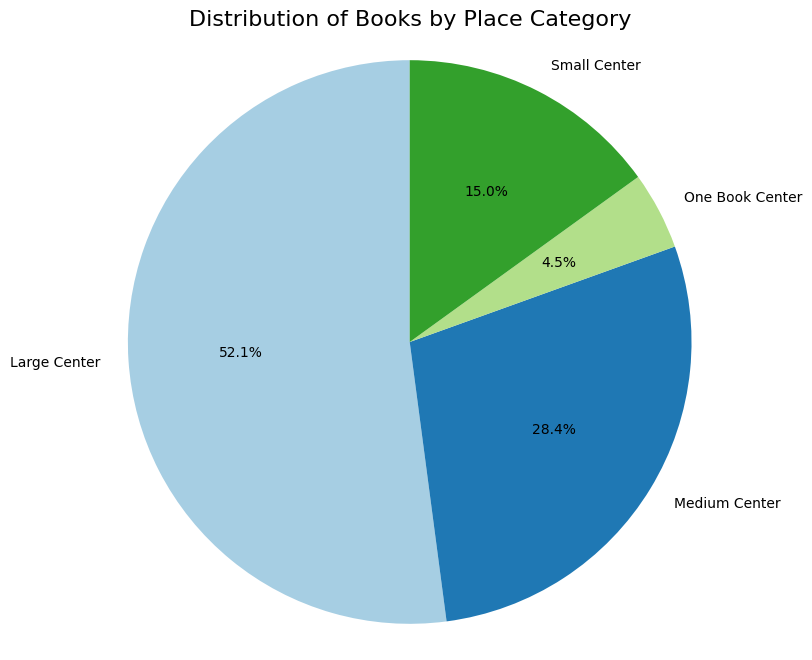

In [22]:
#pie chart: number of books by place category

# Group by 'place_category' and count the number of unique books in each category
books_per_place_category = books.groupby('place_category')['book'].nunique()

# Plotting the pie chart
plt.figure(figsize=(8, 8))

# Create a pie chart
plt.pie(books_per_place_category, labels=books_per_place_category.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Add a title
plt.title('Distribution of Books by Place Category', fontsize=16)

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/books_per_place_category.png', dpi=300)

# Show the plot
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()


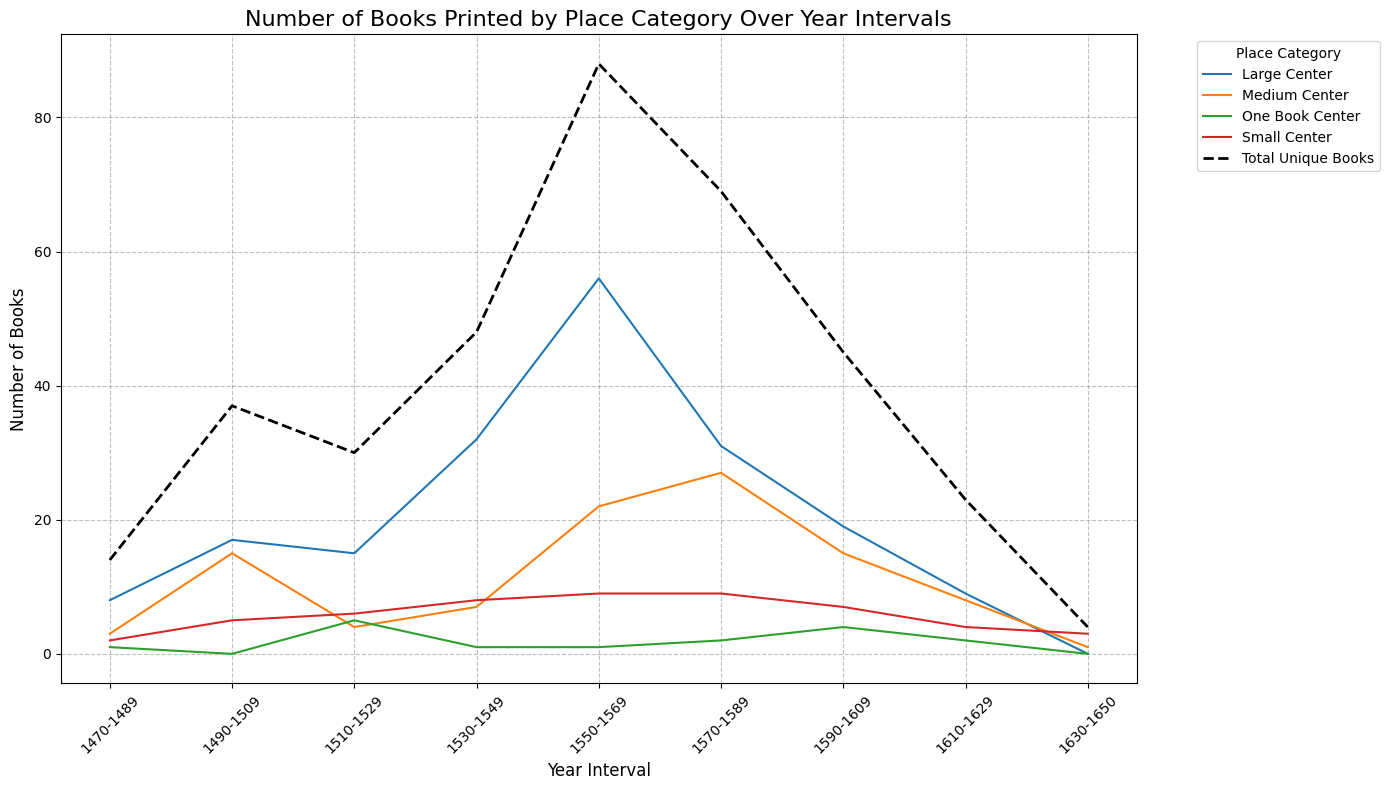

In [23]:

# Group by 'year_interval' and 'place_category' and count the number of unique books in each category
books_per_interval_and_place = books.groupby(['year_interval', 'place_category'])['book'].nunique().reset_index()

# Pivot the table to have 'year_interval' as rows and 'place_category' as columns
books_per_interval_and_place_pivot = books_per_interval_and_place.pivot_table(index='year_interval', 
                                                                             columns='place_category', 
                                                                             values='book', 
                                                                             aggfunc='sum').fillna(0)

# Calculate the total number of unique books per year_interval (sum across all place categories)
total_books_per_interval = books_per_interval_and_place_pivot.sum(axis=1)

# Plotting the results
plt.figure(figsize=(14, 8))

# Plot each place category as a separate line
for place_category in books_per_interval_and_place_pivot.columns:
    plt.plot(books_per_interval_and_place_pivot.index, 
             books_per_interval_and_place_pivot[place_category], 
             label=place_category)

# Plot the total unique books as a broken black line
plt.plot(books_per_interval_and_place_pivot.index, 
         total_books_per_interval, 
         label='Total Unique Books', color='black', linestyle='--', linewidth=2)

# Add titles and labels
plt.title('Number of Books Printed by Place Category Over Year Intervals', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display legend
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid to the background
plt.grid(True, linestyle='--', which='both', axis='both', color='gray', alpha=0.5)

# Improve layout to prevent label clipping
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/num_book_cat_time.png', dpi=300)

# Show the plot
plt.show()


In [71]:
# # Group by 'year_interval' and 'place_category' and count the number of unique books in each category
# books_per_interval_and_place = books.groupby(['year_interval', 'place_category'])['book'].nunique().reset_index()

# # Pivot the table to have 'year_interval' as rows and 'place_category' as columns
# books_per_interval_and_place_pivot = books_per_interval_and_place.pivot_table(index='year_interval', 
#                                                                              columns='place_category', 
#                                                                              values='book', 
#                                                                              aggfunc='sum').fillna(0)

# # Calculate the total number of unique books per place_category (sum across all year_intervals)
# total_books_per_place_category = books_per_interval_and_place_pivot.sum(axis=0)

# # Normalize by dividing each year_interval by the total books for that place_category and multiply by 100 to get percentage
# normalized_books_per_interval = books_per_interval_and_place_pivot.div(total_books_per_place_category, axis=1) * 100

# # Plotting the results
# plt.figure(figsize=(14, 8))

# # Plot each place category as a separate line
# for place_category in normalized_books_per_interval.columns:
#     plt.plot(normalized_books_per_interval.index, 
#              normalized_books_per_interval[place_category], 
#              label=place_category)

# # Add titles and labels
# plt.title('Percentage of Books Printed in Each Year Interval for Each Place Category', fontsize=16)
# plt.xlabel('Year Interval', fontsize=12)
# plt.ylabel('Percentage of Total Books per Place Category (%)', fontsize=12)

# # Rotate x-axis labels for better readability
# plt.xticks(rotation=45)

# # Display legend
# plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# # Add grid to the background
# plt.grid(True, linestyle='--', which='both', axis='both', color='gray', alpha=0.5)

# # Improve layout to prevent label clipping
# plt.tight_layout()

# # Save the plot
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/percentage_book_cat_time.png', dpi=300)

# # Show the plot
# plt.show()


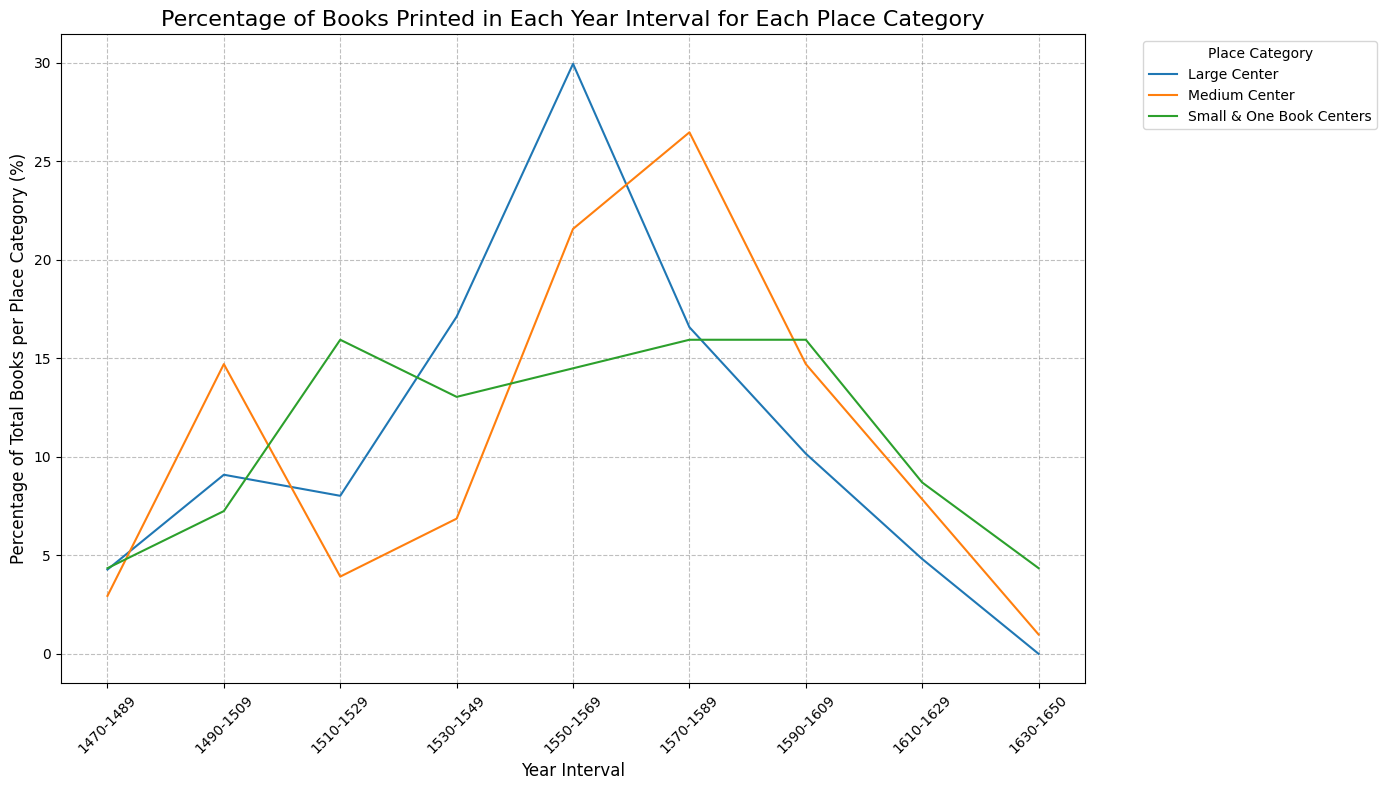

In [70]:
# Combine "Small Centers" and "One Book Centers" into one category: "Small & One Book Centers"
books['place_category_combined'] = books['place_category'].replace({
    'Small Center': 'Small & One Book Centers',
    'One Book Center': 'Small & One Book Centers'
})

# Group by 'year_interval' and the new combined 'place_category_combined', and count the number of unique books in each category
books_per_interval_and_place_combined = books.groupby(['year_interval', 'place_category_combined'])['book'].nunique().reset_index()

# Pivot the table to have 'year_interval' as rows and 'place_category_combined' as columns
books_per_interval_and_place_combined_pivot = books_per_interval_and_place_combined.pivot_table(index='year_interval', 
                                                                                           columns='place_category_combined', 
                                                                                           values='book', 
                                                                                           aggfunc='sum').fillna(0)

# Calculate the total number of unique books per place_category_combined (sum across all year_intervals)
total_books_per_place_combined = books_per_interval_and_place_combined_pivot.sum(axis=0)

# Normalize by dividing each year_interval by the total books for that place_category_combined and multiply by 100 to get percentage
normalized_books_per_interval_combined = books_per_interval_and_place_combined_pivot.div(total_books_per_place_combined, axis=1) * 100

# Plotting the results
plt.figure(figsize=(14, 8))

# Plot each place category as a separate line
for place_category in normalized_books_per_interval_combined.columns:
    plt.plot(normalized_books_per_interval_combined.index, 
             normalized_books_per_interval_combined[place_category], 
             label=place_category)

# Add titles and labels
plt.title('Percentage of Books Printed in Each Year Interval for Each Place Category', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Percentage of Total Books per Place Category (%)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display legend
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid to the background
plt.grid(True, linestyle='--', which='both', axis='both', color='gray', alpha=0.5)

# Improve layout to prevent label clipping
plt.tight_layout()

# Save the plot
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/percentage_book_cat_combined.png', dpi=300)

# Show the plot
plt.show()


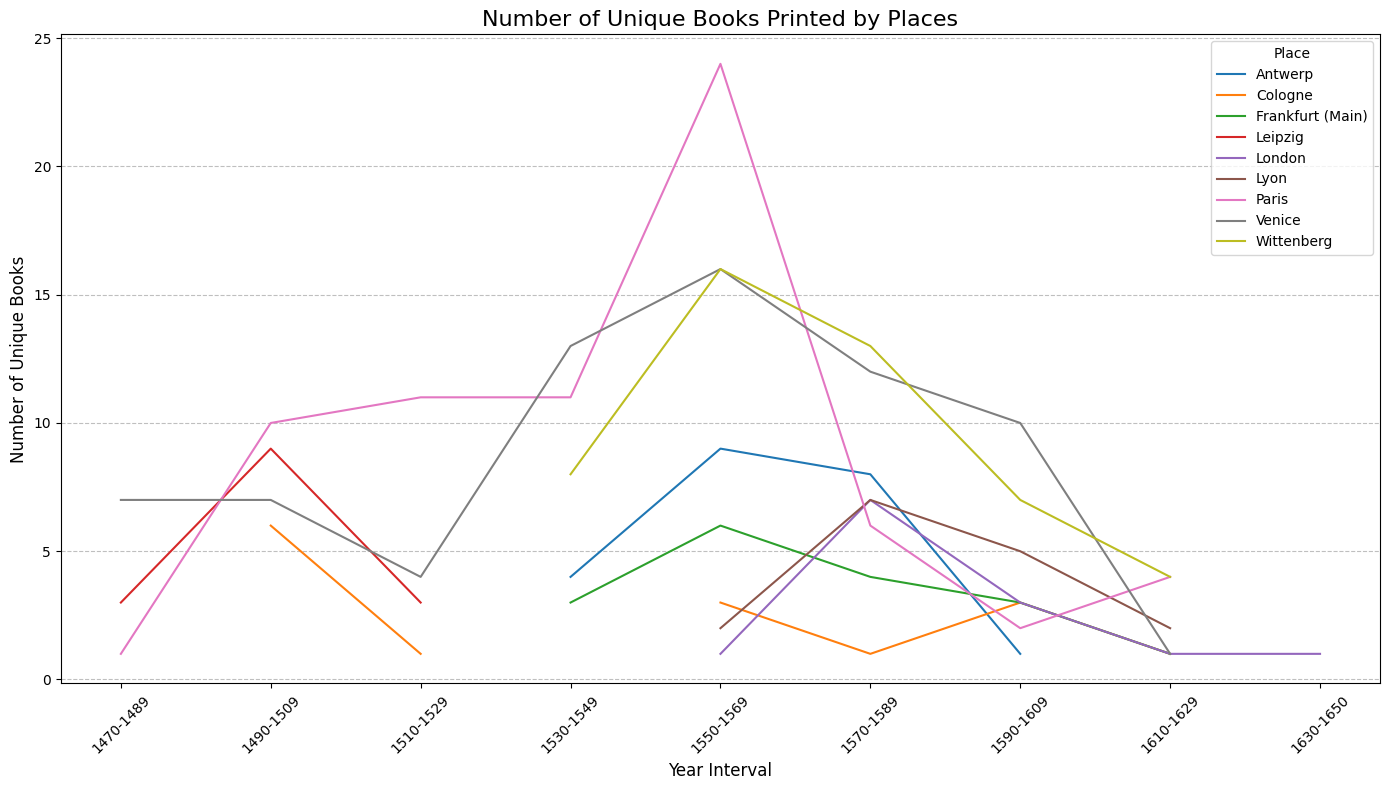

In [68]:

# Filter the books DataFrame to include only rows where place_category is 'large_centers' or 'medium_centers'
filtered_books = books[books['place_category'].isin(['Large Center', 'Medium Center'])]

# Group by 'place' and 'year_interval', and count the number of unique books in each group
books_per_place_year = filtered_books.groupby(['place', 'year_interval'])['book'].nunique().reset_index()

# Pivot the data to get each place as a column and the number of unique books per year_interval as the values
books_per_place_pivot = books_per_place_year.pivot(index='year_interval', columns='place', values='book')

# Plotting the results
plt.figure(figsize=(14, 8))

# Plot each place's line
for place in books_per_place_pivot.columns:
    plt.plot(books_per_place_pivot.index, books_per_place_pivot[place], label=place)

# # Add a black dashed line for total unique books (sum of all places per year_interval)
# total_books_per_year_interval = books_per_place_pivot.sum(axis=1)
# plt.plot(books_per_place_pivot.index, total_books_per_year_interval, color='black', linestyle='--', label='Total Books')

# Add titles and labels
plt.title('Number of Unique Books Printed by Places', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Number of Unique Books', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add a grid
plt.grid(True, linestyle='--', which='both', axis='y', color='gray', alpha=0.5)

# Add legend to label each line
plt.legend(title='Place', bbox_to_anchor=(1, 1), loc='best')

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/large_medium_places.png', dpi=300)

# Show the plot
plt.tight_layout()
plt.show()


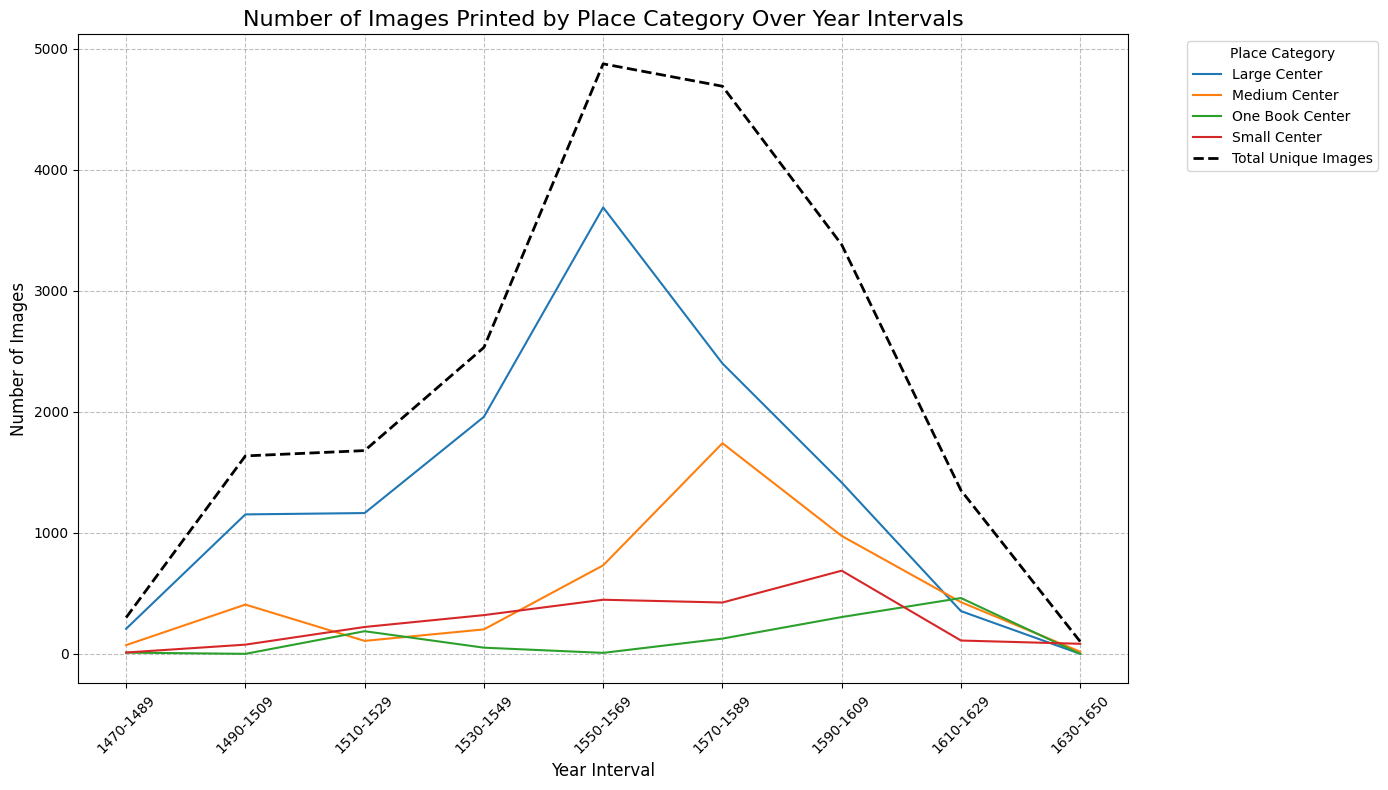

In [76]:

# Group by 'year_interval' and 'place_category' and count the number of unique books in each category
images_per_interval_and_place = df.groupby(['year_interval', 'place_category'])['images'].nunique().reset_index()

# Pivot the table to have 'year_interval' as rows and 'place_category' as columns
images_per_interval_and_place_pivot = images_per_interval_and_place.pivot_table(index='year_interval', 
                                                                             columns='place_category', 
                                                                             values='images', 
                                                                             aggfunc='sum').fillna(0)

# Calculate the total number of unique books per year_interval (sum across all place categories)
total_images_per_interval = images_per_interval_and_place_pivot.sum(axis=1)

# Plotting the results
plt.figure(figsize=(14, 8))

# Plot each place category as a separate line
for place_category in images_per_interval_and_place_pivot.columns:
    plt.plot(images_per_interval_and_place_pivot.index, 
             images_per_interval_and_place_pivot[place_category], 
             label=place_category)

# Plot the total unique books as a broken black line
plt.plot(images_per_interval_and_place_pivot.index, 
         total_images_per_interval, 
         label='Total Unique Images', color='black', linestyle='--', linewidth=2)

# Add titles and labels
plt.title('Number of Images Printed by Place Category Over Year Intervals', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display legend
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid to the background
plt.grid(True, linestyle='--', which='both', axis='both', color='gray', alpha=0.5)

# Improve layout to prevent label clipping
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/context_quantitative_overview/num_images_place_cat_time.png', dpi=300)

# Show the plot
plt.show()
